In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load directly from Google Drive
url = '/content/drive/MyDrive/workbook1detailedexpenditureandtrends.xlsx'

# Read Table 4.1 — time series by category
df_raw = pd.read_excel(url, sheet_name='4.1', header=None)
print('✅ File loaded!')
print(df_raw.shape)

✅ File loaded!
(71, 29)


In [4]:
# Find the exact rows automatically — no guessing
categories_found = {}
for i, row in df_raw.iterrows():
    for j, val in enumerate(row):
        if isinstance(val, str):
            if 'Food' in val and 'non-alcoholic' in val:
                categories_found['Food & non-alcoholic drinks'] = i
            elif 'Alcoholic' in val:
                categories_found['Alcoholic drinks & tobacco'] = i
            elif 'Clothing' in val:
                categories_found['Clothing & footwear'] = i
            elif 'Housing' in val and 'fuel' in val:
                categories_found['Housing, fuel & power'] = i
            elif 'Household goods' in val:
                categories_found['Household goods & services'] = i
            elif val.strip() == 'Health':
                categories_found['Health'] = i
            elif 'Transport' in val and 'Communication' not in val:
                categories_found['Transport'] = i
            elif 'Communication' in val:
                categories_found['Communication'] = i
            elif 'Recreation' in val:
                categories_found['Recreation & culture'] = i
            elif 'Education' in val and 'age' not in val:
                categories_found['Education'] = i
            elif 'Restaurants' in val:
                categories_found['Restaurants & hotels'] = i
            elif 'Miscellaneous' in val:
                categories_found['Miscellaneous goods'] = i

print('Found rows:')
for k, v in categories_found.items():
    print(f'  {k}: row {v}')

Found rows:
  Food & non-alcoholic drinks: row 20
  Alcoholic drinks & tobacco: row 22
  Clothing & footwear: row 24
  Housing, fuel & power: row 26
  Household goods & services: row 28
  Health: row 30
  Transport: row 32
  Communication: row 64
  Recreation & culture: row 36
  Education: row 38
  Restaurants & hotels: row 40
  Miscellaneous goods: row 42


In [5]:
# Build clean dataframe using correct row numbers
years = ['2001-02','2002-03','2003-04','2004-05','2005-06',
         '2006','2007','2008','2009','2010','2011','2012',
         '2013','2014','2014-15','2015-16','2016-17','2017-18',
         '2018-19','2019-20','2020-21','2021-22','2022-23','2023-24']

data = {}
for cat, row_idx in categories_found.items():
    row = df_raw.iloc[row_idx, 4:28].values
    data[cat] = pd.to_numeric(row, errors='coerce')

df = pd.DataFrame(data, index=years)
print('✅ Data ready!')
print(df.tail(3))

✅ Data ready!
         Food & non-alcoholic drinks  Alcoholic drinks & tobacco  \
2021-22                         89.4                        16.9   
2022-23                         79.0                        14.1   
2023-24                         70.6                        11.9   

         Clothing & footwear  Housing, fuel & power  \
2021-22                 17.1                  112.3   
2022-23                 20.0                  111.5   
2023-24                 17.8                  109.0   

         Household goods & services  Health  Transport  Communication  \
2021-22                        41.5     7.6       72.3            NaN   
2022-23                        39.5    10.2       80.8            NaN   
2023-24                        36.8     9.6       79.0            NaN   

         Recreation & culture  Education  Restaurants & hotels  \
2021-22                  52.1        9.3                  22.7   
2022-23                  62.5        5.6                  41.3   
2

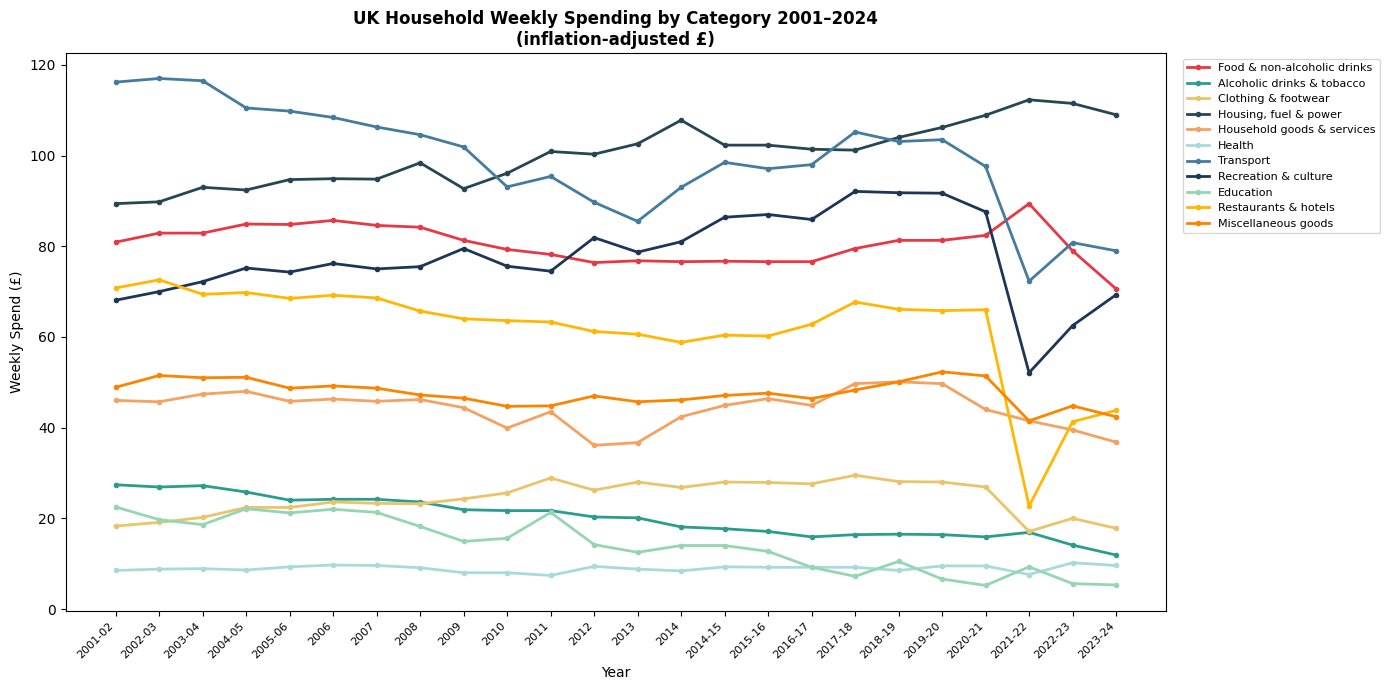

✅ Chart 1 done!


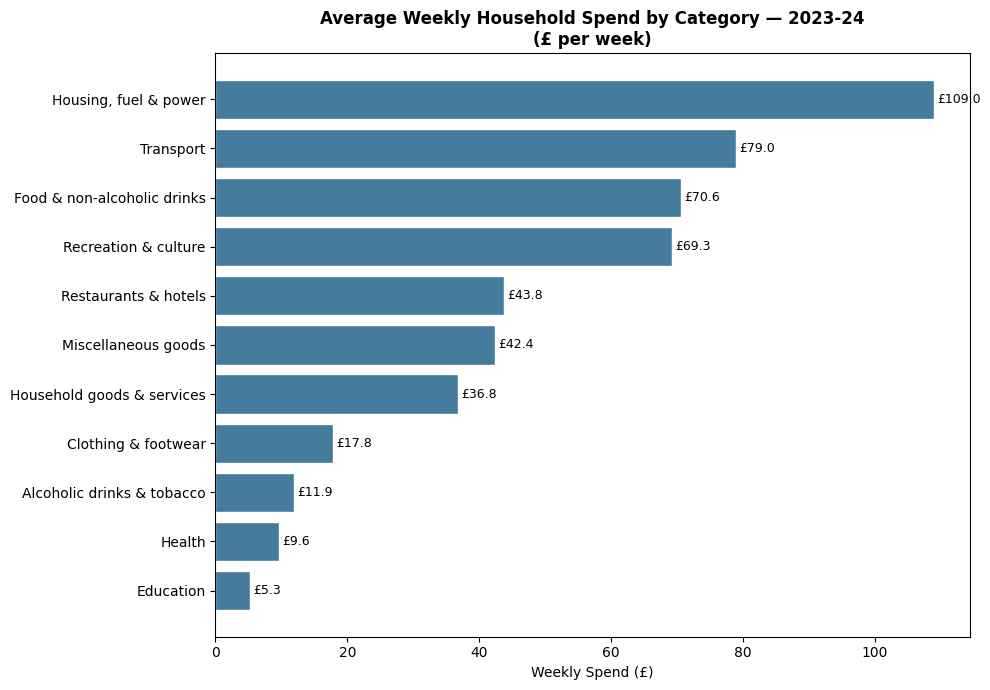

✅ Chart 2 done!


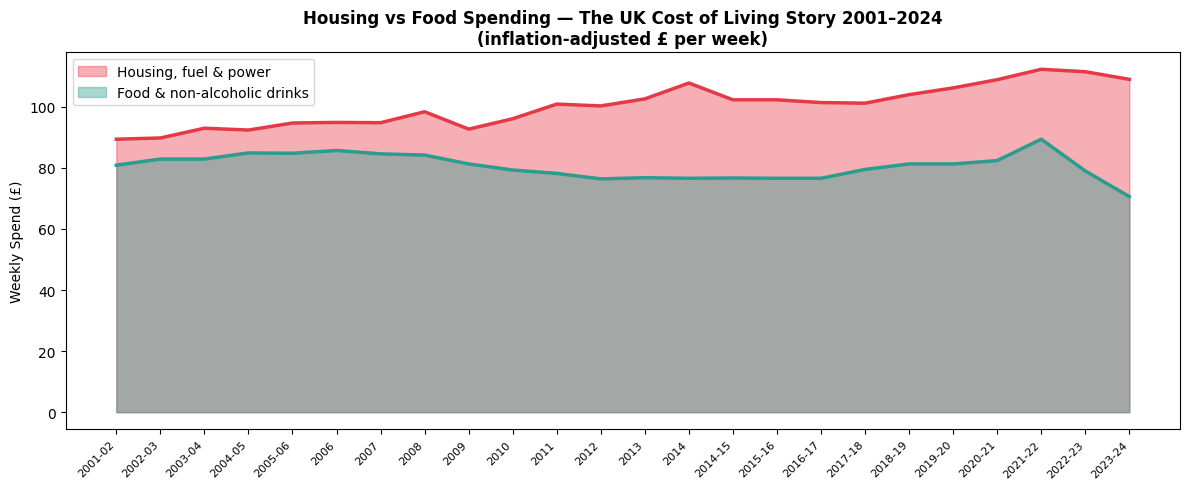

✅ Chart 3 done!


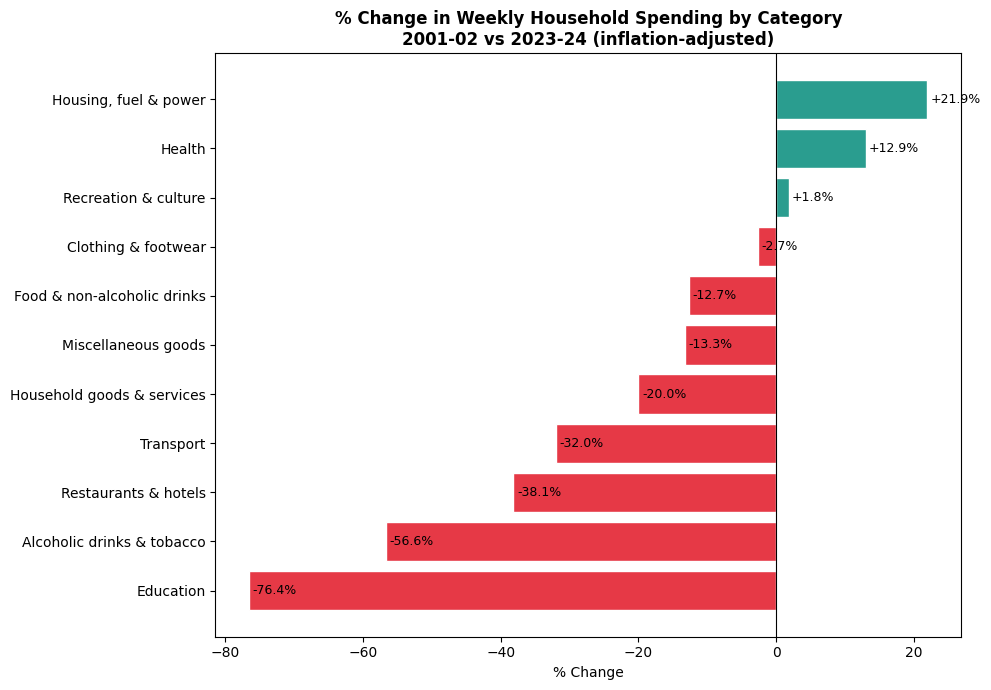

✅ Chart 4 done!


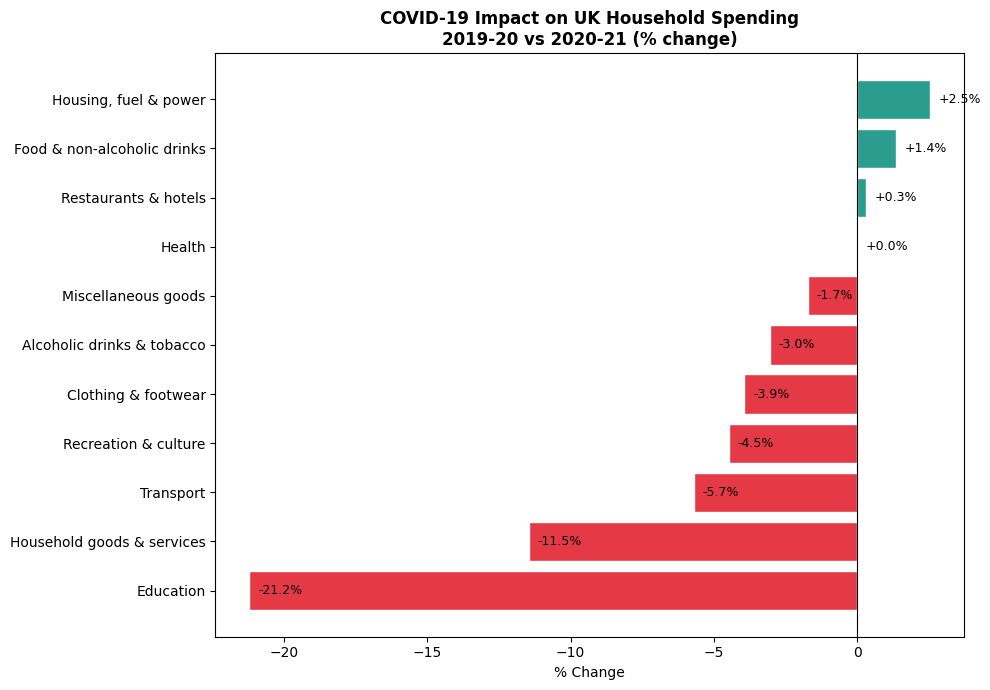

✅ Chart 5 done!

🎉 All 5 charts complete!


In [6]:
import numpy as np

# Drop Communication (missing data)
df_clean = df.drop(columns=['Communication']).dropna()

colors = ['#e63946','#2a9d8f','#e9c46a','#264653','#f4a261',
          '#a8dadc','#457b9d','#1d3557','#95d5b2','#ffb703','#fb8500']

# ── CHART 1 — All category trends over time ──────────────────
fig, ax = plt.subplots(figsize=(14, 7))
for i, col in enumerate(df_clean.columns):
    ax.plot(df_clean.index, df_clean[col], marker='o', markersize=3,
            linewidth=2, label=col, color=colors[i % len(colors)])
ax.set_title('UK Household Weekly Spending by Category 2001–2024\n(inflation-adjusted £)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Weekly Spend (£)')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('ons_chart1.png', bbox_inches='tight')
plt.show()
print('✅ Chart 1 done!')

# ── CHART 2 — 2023-24 spending per category (bar chart) ──────
latest = df_clean.loc['2023-24'].sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(latest.index, latest.values, color='#457b9d', edgecolor='white')
for bar, val in zip(bars, latest.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'£{val:.1f}', va='center', fontsize=9)
ax.set_title('Average Weekly Household Spend by Category — 2023-24\n(£ per week)', fontweight='bold')
ax.set_xlabel('Weekly Spend (£)')
plt.tight_layout()
plt.savefig('ons_chart2.png', bbox_inches='tight')
plt.show()
print('✅ Chart 2 done!')

# ── CHART 3 — Housing vs Food over time (cost of living) ─────
fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(df_clean.index, df_clean['Housing, fuel & power'],
                alpha=0.4, color='#e63946', label='Housing, fuel & power')
ax.fill_between(df_clean.index, df_clean['Food & non-alcoholic drinks'],
                alpha=0.4, color='#2a9d8f', label='Food & non-alcoholic drinks')
ax.plot(df_clean.index, df_clean['Housing, fuel & power'],
        color='#e63946', linewidth=2.5)
ax.plot(df_clean.index, df_clean['Food & non-alcoholic drinks'],
        color='#2a9d8f', linewidth=2.5)
ax.set_title('Housing vs Food Spending — The UK Cost of Living Story 2001–2024\n(inflation-adjusted £ per week)', fontweight='bold')
ax.set_ylabel('Weekly Spend (£)')
ax.legend(fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('ons_chart3.png', bbox_inches='tight')
plt.show()
print('✅ Chart 3 done!')

# ── CHART 4 — % change from 2001 to 2024 ────────────────────
first = df_clean.loc['2001-02']
last  = df_clean.loc['2023-24']
pct_change = ((last - first) / first * 100).sort_values()

bar_colors = ['#e63946' if v < 0 else '#2a9d8f' for v in pct_change.values]
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(pct_change.index, pct_change.values, color=bar_colors, edgecolor='white')
for bar, val in zip(bars, pct_change.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('% Change in Weekly Household Spending by Category\n2001-02 vs 2023-24 (inflation-adjusted)', fontweight='bold')
ax.set_xlabel('% Change')
plt.tight_layout()
plt.savefig('ons_chart4.png', bbox_inches='tight')
plt.show()
print('✅ Chart 4 done!')

# ── CHART 5 — COVID impact 2019-20 vs 2020-21 ───────────────
pre_covid  = df_clean.loc['2019-20']
covid      = df_clean.loc['2020-21']
covid_change = ((covid - pre_covid) / pre_covid * 100).sort_values()

bar_colors2 = ['#e63946' if v < 0 else '#2a9d8f' for v in covid_change.values]
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(covid_change.index, covid_change.values, color=bar_colors2, edgecolor='white')
for bar, val in zip(bars, covid_change.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('COVID-19 Impact on UK Household Spending\n2019-20 vs 2020-21 (% change)', fontweight='bold')
ax.set_xlabel('% Change')
plt.tight_layout()
plt.savefig('ons_chart5.png', bbox_inches='tight')
plt.show()
print('✅ Chart 5 done!')
print('\n🎉 All 5 charts complete!')